<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<h2 style="color:#C00000;">Objectif de ce notebook et ce qui change dans cette version</h2>
<p><b>Ce que je fais ici.</b> Je rapproche les trois exports de BottleNeck (ERP, site web, table de liaison), je detecte et je documente les anomalies de donnees, puis je produis les analyses demandees par Nicolas pour le comite de direction : chiffre d'affaires, palmares et loi de Pareto, valeurs aberrantes de prix, stocks, marges et correlations.</p>
<p><b>Ce qui change par rapport a la version du projet 6.</b> Cette version 2 reprend le notebook initial et l'ameliore sur trois axes, dans l'ordre de priorite fixe dans le cahier des charges :</p>
<ol>
<li><b>Fiabilite</b> : un bloc de controles qualite automatises s'execute des le chargement (section 1.3) et un controle final verifie que le jeu de donnees nettoye respecte toutes les regles (etape 6). Les anomalies sont consolidees dans un tableau recapitulatif avec correction et recommandation.</li>
<li><b>Conformite</b> : une section RGPD inventorie les colonnes de l'export web et ecarte explicitement la colonne a caractere personnel (section 2.2).</li>
<li><b>Reproductibilite</b> : chemins relatifs, versions affichees et figees dans requirements.txt, graine fixee, notebook executable de bout en bout depuis un environnement vierge.</li>
</ol>
<p>Les analyses ont aussi ete completees : valorisation du stock au prix d'achat, correlations etendues aux six variables demandees, charte graphique unique pour les figures de restitution.</p>
<p><b>Convention de lecture.</b> Tout ce qui est en <b>rouge</b> a ete ajoute ou modifie dans cette version 2. Le reste est le travail d'origine du projet 6, conserve tel quel. Dans les cellules de code, les ajouts commencent par le commentaire <code>[AJOUT v2]</code> et les modifications par <code>[MODIFIE v2]</code>.</p>
<p><b>Tracabilite de l'usage de l'IA.</b> Les cellules des sections 1.3, 3.2 (controle inter-tables), 5.3 (valorisation au prix d'achat) et 6 ont ete construites avec l'aide d'un assistant IA. Chaque proposition a ete testee sur des cas dont le resultat etait connu avant d'etre conservee. Les prompts, les variantes essayees, les resultats et les decisions sont consignes dans <code>logs/journal_ia.md</code>. Aucune donnee reelle de BottleNeck n'a ete transmise a un service en ligne : seuls les noms de colonnes, les types et des valeurs fictives ont ete communiques.</p>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Importation de la librairie numpy
import numpy as np

In [4]:
#Importation de la librairie seaborn
import seaborn as sns

In [5]:
#L'instruction permettant d'afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Modification.</b> La version initiale montait Google Drive avec un chemin absolu propre a mon compte : personne d'autre ne pouvait relancer le notebook. Cette cellule la remplace par un environnement reproductible : chemins relatifs au dossier du projet, affichage des versions des librairies, graine aleatoire fixee, et charte graphique unique pour les figures de restitution.</p>
<p>La librairie <b>Pandera</b> est importee ici. Elle a ete retenue a l'issue de la veille (voir la synthese de veille) pour ecrire les regles de qualite des donnees de facon declarative. La syntaxe d'import <code>pandera.pandas</code> est la syntaxe actuelle : l'acces par le module de premier niveau est en cours d'abandon.</p>
</div>

In [6]:
# [MODIFIE v2] Environnement reproductible : chemins relatifs, versions, graine aleatoire, charte graphique
# Remplace le montage Google Drive de la version initiale, qui ne fonctionnait que sur mon compte.
import sys, platform, warnings, time
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import plotly, openpyxl
import pandera
import pandera.pandas as pa   # syntaxe d'import actuelle de Pandera

# Les avertissements openpyxl sur les styles Excel n'ont aucun impact sur les donnees lues
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Graine fixee par principe : ce notebook ne contient pas d'etape aleatoire, mais la regle vaut pour la suite
SEED = 42
np.random.seed(SEED)

# Dossier des donnees : relatif au dossier du projet, jamais un chemin absolu
# Le notebook est dans notebooks/, les fichiers dans data/ ; si on l'execute depuis la racine, data/ est directement la
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
assert DATA_DIR.exists(), f"Dossier de donnees introuvable : {DATA_DIR.resolve()}"
OUTPUT_DIR = DATA_DIR.parent / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Charte graphique unique pour les figures de restitution (decision de veille : matplotlib / seaborn pour la presentation)
sns.set_theme(style="whitegrid", palette="Blues_r", font_scale=0.9)
plt.rcParams["figure.figsize"] = (9, 4.5)

print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | pandera {pandera.__version__}")
print(f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__} | plotly {plotly.__version__} | openpyxl {openpyxl.__version__}")
print("Dossier des donnees :", DATA_DIR.resolve())
print("Dossier des sorties :", OUTPUT_DIR.resolve())

Python 3.13.9 | pandas 2.2.3 | numpy 2.1.3 | pandera 0.33.1
matplotlib 3.10.0 | seaborn 0.13.2 | plotly 5.24.1 | openpyxl 3.1.5
Dossier des donnees : C:\Users\oubak\Desktop\Data analyst\PROJET 13\projet_bottleneck_ia\data
Dossier des sorties : C:\Users\oubak\Desktop\Data analyst\PROJET 13\projet_bottleneck_ia\outputs


In [7]:
# [MODIFIE v2] Chargement par chemins relatifs (plus aucun chemin Google Drive)
df_web = pd.read_excel(DATA_DIR / "web.xlsx")
df_erp = pd.read_excel(DATA_DIR / "erp.xlsx")
df_liaison = pd.read_excel(DATA_DIR / "liaison.xlsx")

# Copies brutes conservees telles quelles : elles servent aux controles a l'import et au tableau recapitulatif des anomalies
df_erp_brut = df_erp.copy()
df_web_brut = df_web.copy()
df_liaison_brut = df_liaison.copy()

print("ERP :", df_erp.shape, "| WEB :", df_web.shape, "| LIAISON :", df_liaison.shape)

ERP : (825, 6) | WEB : (1513, 29) | LIAISON : (825, 2)


<div style="border: 1px solid #C00000;" >
<h3 style="margin: auto; padding: 20px; color: #C00000; ">1.3 - Controles qualite automatises a l'import <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Pourquoi cette section.</b> Dans la version initiale, toutes les anomalies ont ete trouvees a la main, cellule par cellule. Rien ne garantissait qu'elles seraient toutes revues le mois suivant, ni qu'un type d'anomalie nouveau serait repere. Cette section execute les memes verifications automatiquement, des le chargement, et produit un rapport lisible sans lire le code.</p>
<p><b>Les regles, ecrites en francais avant d'etre codees.</b> C'est le point de depart : si je ne sais pas ce que je veux verifier, aucun outil ne m'aidera.</p>
<table style="border-collapse:collapse; color:#C00000;">
<tr><th style="border:1px solid #C00000; padding:4px 8px;">Table</th><th style="border:1px solid #C00000; padding:4px 8px;">Regle</th><th style="border:1px solid #C00000; padding:4px 8px;">Pourquoi</th></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP</td><td style="border:1px solid #C00000; padding:4px 8px;">product_id unique et renseigne</td><td style="border:1px solid #C00000; padding:4px 8px;">C'est la cle de jointure</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP</td><td style="border:1px solid #C00000; padding:4px 8px;">price et purchase_price strictement positifs</td><td style="border:1px solid #C00000; padding:4px 8px;">Un prix negatif ou nul n'a pas de sens metier</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP</td><td style="border:1px solid #C00000; padding:4px 8px;">stock_quantity non negatif</td><td style="border:1px solid #C00000; padding:4px 8px;">Un stock negatif signale un exces de sorties enregistrees</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP</td><td style="border:1px solid #C00000; padding:4px 8px;">stock_status dans {instock, outofstock} et coherent avec la quantite</td><td style="border:1px solid #C00000; padding:4px 8px;">Le statut doit decouler de la quantite</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP</td><td style="border:1px solid #C00000; padding:4px 8px;">onsale_web vaut 0 ou 1</td><td style="border:1px solid #C00000; padding:4px 8px;">Indicateur binaire</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">WEB</td><td style="border:1px solid #C00000; padding:4px 8px;">sku numerique, total_sales non negatif, post_type et tax_status connus</td><td style="border:1px solid #C00000; padding:4px 8px;">Regle de codification et coherence des ventes</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">LIAISON</td><td style="border:1px solid #C00000; padding:4px 8px;">product_id unique, id_web numerique quand il est renseigne</td><td style="border:1px solid #C00000; padding:4px 8px;">Fiabilite de la passerelle entre les deux systemes</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">ERP / WEB</td><td style="border:1px solid #C00000; padding:4px 8px;">Taux de non-correspondance mesure et compare a la reference</td><td style="border:1px solid #C00000; padding:4px 8px;">Regle inter-tables, traitee a l'etape 3.2</td></tr>
</table>
<p><b>Demarche comparative.</b> Ces regles sont codees de deux facons differentes, puis comparees sur les vraies donnees : l'option A avec la librairie Pandera, l'option B avec des controles pandas ecrits a la main avec l'aide d'un assistant IA. La decision est prise a la fin de la section, sur la base des resultats observes et non d'un a priori.</p>
</div>

In [8]:
# [AJOUT v2] Option A : controles declaratifs avec Pandera
# Principe : chaque regle est ecrite une fois, en clair, et Pandera l'applique a toutes les lignes.
# lazy=True : on collecte TOUTES les anomalies au lieu de s'arreter a la premiere rencontree.

def rapport_pandera(schema, df, cle, nom_table):
    """Valide df contre schema et renvoie (rapport, conforme).
    rapport : une ligne par regle en defaut, avec le nombre de lignes concernees et des exemples d'identifiants.
    conforme : True si aucune regle n'est violee."""
    colonnes_rapport = ["table", "regle", "colonne", "nb_lignes", "exemples"]
    try:
        schema.validate(df, lazy=True)
        return pd.DataFrame(columns=colonnes_rapport), True
    except pa.errors.SchemaErrors as erreurs:
        fc = erreurs.failure_cases.copy()
        # Une regle de colonne est rattachee a sa colonne ; une regle de table (qui porte sur plusieurs colonnes) est regroupee par regle
        fc["colonne"] = np.where(fc["schema_context"] == "Column", fc["column"], "plusieurs colonnes")
        lignes = []
        for (colonne, regle), g in fc.groupby(["colonne", "check"], dropna=False):
            idx = g["index"].dropna().astype(int).unique()
            exemples = [e if pd.notna(e) else "sans code article" for e in df.loc[idx, cle].head(5)] if len(idx) else []
            lignes.append({"table": nom_table, "regle": regle, "colonne": colonne,
                           "nb_lignes": int(len(idx)), "exemples": exemples})
        rapport = pd.DataFrame(lignes, columns=colonnes_rapport).sort_values("nb_lignes", ascending=False).reset_index(drop=True)
        return rapport, False


# Schema de l'ERP : les regles metier en clair
schema_erp = pa.DataFrameSchema(
    columns={
        "product_id":     pa.Column(int, unique=True, nullable=False),
        "onsale_web":     pa.Column(int, pa.Check.isin([0, 1], error="onsale_web vaut 0 ou 1")),
        "price":          pa.Column(float, pa.Check.gt(0, error="prix de vente strictement positif"), nullable=False),
        "stock_quantity": pa.Column(int, pa.Check.ge(0, error="stock non negatif"), nullable=False),
        "stock_status":   pa.Column(checks=pa.Check.isin(["instock", "outofstock"], error="statut de stock connu")),
        "purchase_price": pa.Column(float, pa.Check.gt(0, error="prix d'achat strictement positif"), nullable=False),
    },
    checks=[
        pa.Check(lambda d: (d["stock_quantity"] > 0) == (d["stock_status"] == "instock"),
                 error="coherence statut / quantite de stock"),
    ],
    name="ERP",
)

# Schema de l'export web brut : on controle ce qui arrive du site, avant tout nettoyage
# Les colonnes texte sont declarees sans type pour rester compatibles avec toutes les versions de pandas
def est_numerique(s):
    return s.isna() | s.astype(str).str.fullmatch(r"\d+")

schema_web_brut = pa.DataFrameSchema(
    columns={
        "sku":         pa.Column(nullable=True, checks=pa.Check(est_numerique, error="code article numerique")),
        "post_type":   pa.Column(nullable=True, checks=pa.Check.isin(["product", "attachment"], error="type de ligne connu")),
        "total_sales": pa.Column(float, pa.Check.ge(0, error="ventes non negatives"), nullable=True),
        "tax_status":  pa.Column(nullable=True, checks=pa.Check.isin(["taxable", "none"], error="statut fiscal connu")),
    },
    name="WEB_BRUT",
)

# Schema de la table de liaison
schema_liaison = pa.DataFrameSchema(
    columns={
        "product_id": pa.Column(int, unique=True, nullable=False),
        "id_web":     pa.Column(nullable=True, checks=pa.Check(est_numerique, error="identifiant web numerique")),
    },
    name="LIAISON",
)

debut = time.perf_counter()
rapport_erp_A, erp_conforme = rapport_pandera(schema_erp, df_erp_brut, "product_id", "erp")
rapport_web_A, web_conforme = rapport_pandera(schema_web_brut, df_web_brut, "sku", "web")
rapport_liaison_A, liaison_conforme = rapport_pandera(schema_liaison, df_liaison_brut, "product_id", "liaison")
duree_A = time.perf_counter() - debut

rapport_A = pd.concat([rapport_erp_A, rapport_web_A, rapport_liaison_A], ignore_index=True)
print(f"Option A (Pandera) : {len(rapport_A)} regle(s) en defaut, {rapport_A['nb_lignes'].sum()} ligne(s) concernee(s), {duree_A:.3f} s")
rapport_A

Option A (Pandera) : 6 regle(s) en defaut, 16 ligne(s) concernee(s), 0.201 s


,table,regle,colonne,nb_lignes,exemples
0,erp,prix de vente strictement positif,price,3,"[5017, 6594, 4233]"
1,erp,coherence statut / quantite de stock,plusieurs colonnes,2,"[4885, 4039]"
2,erp,stock non negatif,stock_quantity,2,"[5700, 4973]"
3,web,code article numerique,sku,4,"[13127-1, bon-cadeau-25-euros, 13127-1, bon-ca..."
4,web,ventes non negatives,total_sales,2,"[sans code article, sans code article]"
5,liaison,identifiant web numerique,id_web,3,"[4954, 7247, 7329]"


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Lecture du rapport.</b> Chaque ligne est une regle violee, avec le nombre de lignes concernees et jusqu'a cinq identifiants pour aller verifier. Le rapport retrouve les anomalies que j'avais identifiees a la main dans le projet 6 : trois prix negatifs, deux stocks negatifs, deux incoherences entre statut et quantite, deux codes articles hors format sur le site (chacun present sur deux lignes, la fiche produit et sa piece jointe) et trois identifiants hors format dans la liaison.</p>
<p><b>Il revele aussi quelque chose que la revue manuelle n'avait pas vu</b> : deux lignes de l'export web portent des quantites vendues negatives. Dans la version initiale, ces lignes n'avaient pas de code article et ont ete supprimees avec les lignes vides, sans que la valeur negative soit remarquee. Elle est ajoutee au tableau recapitulatif des anomalies (etape 6). C'est exactement l'interet d'un controle automatise : il verifie ce qu'on ne pense pas a regarder.</p>
</div>

In [9]:
# [AJOUT v2] Option B : les memes regles, ecrites en pandas avec l'aide d'un assistant IA
# Principe : une fonction par table, un masque booleen par regle, et on compte les lignes en defaut.
# Le code propose par l'assistant a ete relu et teste (cellule suivante) avant d'etre conserve.

def _rapport_depuis_masques(df, masques, cle, nom_table):
    lignes = [{"table": nom_table, "regle": regle, "nb_lignes": int(m.sum()),
               "exemples": [e if pd.notna(e) else "sans code article" for e in df.loc[m, cle].head(5)]}
              for regle, m in masques.items() if m.sum() > 0]
    return pd.DataFrame(lignes, columns=["table", "regle", "nb_lignes", "exemples"]) \
             .sort_values("nb_lignes", ascending=False).reset_index(drop=True)

def controles_pandas_erp(df):
    masques = {
        "identifiant produit unique":           df["product_id"].duplicated(keep=False) | df["product_id"].isna(),
        "onsale_web vaut 0 ou 1":               ~df["onsale_web"].isin([0, 1]),
        "prix de vente strictement positif":    ~(df["price"] > 0),
        "stock non negatif":                    ~(df["stock_quantity"] >= 0),
        "statut de stock connu":                ~df["stock_status"].isin(["instock", "outofstock"]),
        "prix d'achat strictement positif":     ~(df["purchase_price"] > 0),
        "coherence statut / quantite de stock": (df["stock_quantity"] > 0) != (df["stock_status"] == "instock"),
    }
    return _rapport_depuis_masques(df, masques, "product_id", "erp")

def controles_pandas_web(df):
    sku_txt = df["sku"].astype(str)
    masques = {
        "code article numerique":   df["sku"].notna() & ~sku_txt.str.fullmatch(r"\d+"),
        "type de ligne connu":      df["post_type"].notna() & ~df["post_type"].isin(["product", "attachment"]),
        "ventes non negatives":     df["total_sales"].notna() & (df["total_sales"] < 0),
        "statut fiscal connu":      df["tax_status"].notna() & ~df["tax_status"].isin(["taxable", "none"]),
        # Deux regles supplementaires que pandas exprime facilement et qui expliquent la structure de l'export
        "ligne sans code article":  df["sku"].isna(),
        "code article present sur plusieurs lignes (produit et piece jointe)": df["sku"].notna() & df["sku"].duplicated(keep=False),
    }
    return _rapport_depuis_masques(df, masques, "sku", "web")

def controles_pandas_liaison(df):
    masques = {
        "identifiant produit unique":  df["product_id"].duplicated(keep=False) | df["product_id"].isna(),
        "identifiant web numerique":   df["id_web"].notna() & ~df["id_web"].astype(str).str.fullmatch(r"\d+"),
        "identifiant web manquant":    df["id_web"].isna(),
    }
    return _rapport_depuis_masques(df, masques, "product_id", "liaison")

debut = time.perf_counter()
rapport_erp_B = controles_pandas_erp(df_erp_brut)
rapport_web_B = controles_pandas_web(df_web_brut)
rapport_liaison_B = controles_pandas_liaison(df_liaison_brut)
duree_B = time.perf_counter() - debut

rapport_B = pd.concat([rapport_erp_B, rapport_web_B, rapport_liaison_B], ignore_index=True)
print(f"Option B (pandas) : {len(rapport_B)} regle(s) en defaut, {rapport_B['nb_lignes'].sum()} ligne(s) concernee(s), {duree_B:.3f} s")
rapport_B

Option B (pandas) : 9 regle(s) en defaut, 1620 ligne(s) concernee(s), 0.034 s


,table,regle,nb_lignes,exemples
0,erp,prix de vente strictement positif,3,"[4233, 5017, 6594]"
1,erp,stock non negatif,2,"[4973, 5700]"
2,erp,coherence statut / quantite de stock,2,"[4039, 4885]"
3,web,code article present sur plusieurs lignes (pro...,1428,"[11862, 16057, 14692, 16295, 15328]"
4,web,ligne sans code article,85,"[sans code article, sans code article, sans co..."
5,web,code article numerique,4,"[13127-1, bon-cadeau-25-euros, 13127-1, bon-ca..."
6,web,ventes non negatives,2,"[sans code article, sans code article]"
7,liaison,identifiant web manquant,91,"[4055, 4090, 4092, 4195, 4209]"
8,liaison,identifiant web numerique,3,"[4954, 7247, 7329]"


In [10]:
# [AJOUT v2] Test des deux options sur des cas dont le resultat est connu
# Les comptages de reference viennent de la revue manuelle du projet 6. Si une option ne les retrouve pas, elle est fausse.
attendu = {
    ("erp", "prix de vente strictement positif"): 3,      # 4233, 5017, 6594
    ("erp", "stock non negatif"): 2,                      # 4973, 5700
    ("erp", "coherence statut / quantite de stock"): 2,   # 4039, 4885
    ("liaison", "identifiant web numerique"): 3,          # bon-cadeau-25-euros, 13127-1, 14680-1
}

def compte(rapport, table, regle):
    sel = rapport[(rapport["table"] == table) & (rapport["regle"] == regle)]
    return int(sel["nb_lignes"].sum())

for (table, regle), n in attendu.items():
    nA, nB = compte(rapport_A, table, regle), compte(rapport_B, table, regle)
    assert nA == n, f"Option A : {regle} -> {nA} au lieu de {n}"
    assert nB == n, f"Option B : {regle} -> {nB} au lieu de {n}"
    print(f"OK  {table:8s} | {regle:40s} | attendu {n} | A = {nA} | B = {nB}")

# Les regles communes aux deux options doivent donner les memes comptages
communes = set(zip(rapport_A["table"], rapport_A["regle"])) & set(zip(rapport_B["table"], rapport_B["regle"]))
ecarts = [(t, r) for (t, r) in communes if compte(rapport_A, t, r) != compte(rapport_B, t, r)]
assert not ecarts, f"Ecarts entre les deux options : {ecarts}"
print(f"\nLes {len(communes)} regles communes donnent des comptages identiques dans les deux options.")

OK  erp      | prix de vente strictement positif        | attendu 3 | A = 3 | B = 3
OK  erp      | stock non negatif                        | attendu 2 | A = 2 | B = 2
OK  erp      | coherence statut / quantite de stock     | attendu 2 | A = 2 | B = 2
OK  liaison  | identifiant web numerique                | attendu 3 | A = 3 | B = 3

Les 6 regles communes donnent des comptages identiques dans les deux options.


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<h3 style="color:#C00000;">Comparaison des deux options et decision</h3>
<table style="border-collapse:collapse; color:#C00000;">
<tr><th style="border:1px solid #C00000; padding:4px 8px;">Critere</th><th style="border:1px solid #C00000; padding:4px 8px;">Option A : Pandera</th><th style="border:1px solid #C00000; padding:4px 8px;">Option B : pandas assiste par IA</th></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Exactitude</td><td style="border:1px solid #C00000; padding:4px 8px;">Retrouve tous les cas connus</td><td style="border:1px solid #C00000; padding:4px 8px;">Retrouve tous les cas connus, apres relecture du code genere</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Lisibilite des regles</td><td style="border:1px solid #C00000; padding:4px 8px;">Le schema se lit comme une liste de contraintes : une colonne, une regle, un message</td><td style="border:1px solid #C00000; padding:4px 8px;">Chaque regle est un masque booleen a decoder ; le signe de negation se lit mal</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Regles inter-tables</td><td style="border:1px solid #C00000; padding:4px 8px;">Non prevu : un schema porte sur une seule table</td><td style="border:1px solid #C00000; padding:4px 8px;">Naturel : le taux de correspondance ERP / web s'ecrit en deux lignes</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Maintenabilite</td><td style="border:1px solid #C00000; padding:4px 8px;">Ajouter une regle = ajouter une ligne dans le schema</td><td style="border:1px solid #C00000; padding:4px 8px;">Ajouter une regle = ecrire et tester un nouveau masque</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Dependances et sobriete</td><td style="border:1px solid #C00000; padding:4px 8px;">Une librairie legere, traitement local</td><td style="border:1px solid #C00000; padding:4px 8px;">Aucune dependance, mais le code depend de ma relecture et des appels a l'assistant</td></tr>
<tr><td style="border:1px solid #C00000; padding:4px 8px;">Temps d'execution</td><td style="border:1px solid #C00000; padding:4px 8px;" colspan="2">Quelques centiemes de seconde dans les deux cas : le critere n'est pas discriminant a cette echelle</td></tr>
</table>
<p><b>Decision.</b> Je retiens <b>Pandera</b> pour toutes les regles qui portent sur une table (option A), parce que les regles restent lisibles par une personne qui ne code pas et que le schema est facile a faire evoluer. Je garde <b>les controles pandas</b> uniquement pour ce que Pandera n'exprime pas, c'est-a-dire la regle inter-tables sur le taux de correspondance (etape 3.2). Cette decision est celle de la veille, mais elle est ici confirmee par l'experimentation sur les donnees reelles.</p>
<p><b>Ce que j'ai appris sur l'usage de l'IA.</b> Le code pandas genere par l'assistant etait correct sur le fond mais deux points ont demande une correction apres test : la regle d'unicite ignorait les valeurs manquantes, et une premiere version du rapport Pandera comptait plusieurs fois la meme ligne pour la regle de coherence, une fois par colonne concernee. Sans le test sur les cas connus, ces erreurs seraient passees. Le detail est dans le journal des essais.</p>
</div>

In [11]:
# [AJOUT v2] Rapport en francais, lisible par une personne non technique
# C'est la sortie destinee a Nicolas et a la personne qui relancera les controles chaque mois.

def afficher_rapport_lisible(rapport, titre):
    print("=" * 78)
    print(titre)
    print("=" * 78)
    if rapport.empty:
        print("Aucune anomalie detectee : toutes les regles sont respectees.")
        return
    for table, grp in rapport.groupby("table", sort=False):
        print(f"\nTable {table.upper()} : {len(grp)} regle(s) en defaut")
        for _, r in grp.iterrows():
            ex = ", ".join(str(e) for e in r["exemples"][:5])
            print(f"  - {r['regle']} : {r['nb_lignes']} ligne(s). Exemples : {ex}")
    print("\nChaque ligne signalee est a verifier dans le systeme source avant correction.")

afficher_rapport_lisible(rapport_A, "CONTROLE QUALITE A L'IMPORT (donnees brutes d'octobre)")

CONTROLE QUALITE A L'IMPORT (donnees brutes d'octobre)

Table ERP : 3 regle(s) en defaut
  - prix de vente strictement positif : 3 ligne(s). Exemples : 5017, 6594, 4233
  - coherence statut / quantite de stock : 2 ligne(s). Exemples : 4885, 4039
  - stock non negatif : 2 ligne(s). Exemples : 5700, 4973

Table WEB : 2 regle(s) en defaut
  - code article numerique : 4 ligne(s). Exemples : 13127-1, bon-cadeau-25-euros, 13127-1, bon-cadeau-25-euros
  - ventes non negatives : 2 ligne(s). Exemples : sans code article, sans code article

Table LIAISON : 1 regle(s) en defaut
  - identifiant web numerique : 3 ligne(s). Exemples : 4954, 7247, 7329

Chaque ligne signalee est a verifier dans le systeme source avant correction.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [12]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [13]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [14]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [15]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
nb_doublons = df_erp["product_id"].duplicated().sum()
print("Nombre de doublons sur product_id :", nb_doublons)

Nombre de doublons sur product_id : 0


On n'a pas de doublons dans la colonne "**product_id**" ce qui veut dire qu'on peut utiliser ce dernier comme ***PREMIER KEY(PK)*** qui sécurise nos futures jointures:

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [16]:
#Les prix non renseignés nuls
nb_prix_manquants = df_erp["price"].isna().sum()
print("Nombres d'articles avec un prix non renseigné: {}".format(nb_prix_manquants))


Nombres d'articles avec un prix non renseigné: 0


In [17]:
#Le prix minimum
prix_min = df_erp["price"].min()
print("Prix minimum: {}".format(prix_min))


Prix minimum: -20.0


In [18]:
#Le prix maximum
prix_max = df_erp["price"].max()
print("Prix maximum: {}".format(prix_max))


Prix maximum: 225.0


In [19]:
# Les prix < 0
prix_negatifs = df_erp[df_erp["price"] < 0][["product_id", "price"]]
prix_negatifs


,product_id,price
151,4233,-20.0
469,5017,-8.0
739,6594,-9.1


Un prix négatif est impossible en vente > c’est une erreur de saisie **(surtout que les valeurs sont réalistes [-20.0; -8.0; -9.1])**.

Il faut corriger ces valeurs en supposant que le signe “-” est une erreur, donc on prend la valeur absolue.

Et on garde une liste des corrections “récap des corrections à mettre en place”.

On a **3 produits** qui ont **des prix négatifs**.

In [20]:
#Sauvegarder les lignes concernées
prix_negatifs_avant = df_erp.loc[df_erp["price"] < 0, ["product_id", "price"]].copy()
prix_negatifs_avant



,product_id,price
151,4233,-20.0
469,5017,-8.0
739,6594,-9.1


In [21]:
#Correction des prix négatifs
df_erp.loc[df_erp["price"] < 0, "price"] = df_erp.loc[df_erp["price"] < 0, "price"].abs()


In [22]:
#Vérification qu'il n'y a plus des prix négatifs
df_erp[df_erp["price"] < 0][["product_id", "price"]]

,product_id,price


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [23]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp["stock_status"].value_counts()


stock_status
instock       733
outofstock     92
Name: count, dtype: int64

**Stock_status** est lié directement à **Stock_quantity**
- stock_quantity > 0 <> stock_status devrait être instock

- stock_quantity = 0 <> stock_status devrait être outofstock

- stock_quantity < 0 <> erreur (stock négatif = erreur de saisie )

In [24]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x == 0 else "instock")



In [25]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [26]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
df_erp["coherence_stock"] = (df_erp["stock_status"] == df_erp["stock_status_2"])
df_erp["coherence_stock"].sum()


np.int64(821)

In [27]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
df_erp[df_erp["coherence_stock"] == False][
    ["product_id", "stock_quantity", "stock_status", "stock_status_2"]
]


,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock
449,4973,-10,outofstock,instock
573,5700,-1,outofstock,instock


4039 : stock_quantity = 3 mais stock_status = outofstock > devrait être instock

4885 : stock_quantity = 0 mais stock_status = instock > devrait être outofstock

4973 : stock_quantity = -10 > stock négatif (anormal)

5700 : stock_quantity = -1 > stock négatif (anormal)
** Suggestion : nouvel inventaire pour mieux verifier les stocks négatifs, il faut savoir d'où cela vient soit un erreur de saisie ou autres raisons (approvisionnement, annulation, retour, conditionnement...)**

In [28]:
# Corriger les stocks négatifs : on les met à 0
df_erp.loc[df_erp["stock_quantity"] < 0, "stock_quantity"] = 0


In [29]:
# Mettre stock_status cohérent avec la quantité
df_erp.loc[df_erp["stock_quantity"] == 0, "stock_status"] = "outofstock"
df_erp.loc[df_erp["stock_quantity"] > 0, "stock_status"] = "instock"


In [30]:
# Recréer stock_status_2 (statut théorique à partir du stock)
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x == 0 else "instock"
)

# Comparaison : True si cohérent, False sinon
df_erp["coherence_stock"] = (df_erp["stock_status"] == df_erp["stock_status_2"])

# Synthèse
print("Lignes cohérentes :", df_erp["coherence_stock"].sum(), "/", df_erp.shape[0])


Lignes cohérentes : 825 / 825


In [31]:
stock_min = df_erp["stock_quantity"].min()
print("Stock minimum:", stock_min)


Stock minimum: 0


In [32]:
stock_max = df_erp["stock_quantity"].max()
print("Stock maximum:", stock_max)


Stock maximum: 145


In [33]:
stocks_negatifs = df_erp[df_erp["stock_quantity"] < 0][["product_id", "stock_quantity"]]
stocks_negatifs


,product_id,stock_quantity


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [34]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient.
df_erp["onsale_web"].value_counts()



onsale_web
1    716
0    109
Name: count, dtype: int64

1 = produit vendu en ligne / visible sur le site

0 = produit non vendu en ligne / non visible sur le site

In [35]:
#Colonnes importantes pour l'analyse de la data

#product_id : identifiant produit ERP (PK)
#price : prix de vente (utile pour CA)
#stock_quantity : stock (rotation, mois de stock)
#stock_status : statut stock (info catégorielle)
#onsale_web : vendu sur le web ou non (filtre important)


In [36]:
#Supprimer la colonne comportant les libellés "coherence_stock" car colonne de contrôle et  "stock_status_2" car cette derniere est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2", "coherence_stock"])




<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [37]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"

#Afficher le prix minimum de la colonne "purchase_price"

#Afficher le prix maximum de la colonne "purchase_price"


In [38]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
nb_pa_manquants = df_erp["purchase_price"].isna().sum()
print("Nombre d'articles avec un prix d'achat non renseigné: {}".format(nb_pa_manquants))


Nombre d'articles avec un prix d'achat non renseigné: 0


In [39]:
#Afficher le prix minimum de la colonne "purchase_price"
pa_min = df_erp["purchase_price"].min()
print("Prix d'achat minimum: {}".format(pa_min))


Prix d'achat minimum: 2.74


In [40]:
#Afficher le prix maximum de la colonne "purchase_price"
pa_max = df_erp["purchase_price"].max()
print("Prix d'achat maximum: {}".format(pa_max))

Prix d'achat maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [41]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques
print("Nombre d'observations :", df_web.shape[0])
print("Nombre de caractéristiques :", df_web.shape[1])



Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [42]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [43]:
#Colonnes importantes pour l'analyse de la data
#"sku", "total_sales","tax_status", "post_type", "product_type"

<div style="border: 1px solid #C00000;" >
<h3 style="margin: auto; padding: 20px; color: #C00000; ">2.2.1 - Conformite RGPD : inventaire des colonnes de l'export web <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Pourquoi cette section.</b> Nicolas demande explicitement de justifier les choix au regard du RGPD. La version initiale ne le faisait pas. Le principe applique est celui de la <b>minimisation</b> : je ne conserve que les colonnes necessaires a l'analyse, et j'ecarte explicitement toute colonne a caractere personnel, meme indirect.</p>
<p>L'inventaire ci-dessous liste les 29 colonnes de l'export web brut avec leur taux de remplissage. Il sert a decider colonne par colonne.</p>
</div>

In [44]:
# [AJOUT v2] Inventaire des colonnes de l'export web brut au regard du RGPD
inventaire_web = pd.DataFrame({
    "colonne": df_web_brut.columns,
    "valeurs_non_nulles": df_web_brut.notna().sum().values,
    "valeurs_distinctes": df_web_brut.nunique().values,
}).reset_index(drop=True)

# Classification : ce que chaque colonne represente et la decision prise
personnelles = ["post_author"]                                  # identifiant de l'utilisateur WordPress ayant cree la fiche
vides        = [c for c in df_web_brut.columns if df_web_brut[c].notna().sum() == 0]
utiles       = ["sku", "total_sales", "tax_status", "post_type", "product_type"]

def decision(c):
    if c in personnelles: return "ECARTEE : donnee a caractere personnel (identifiant d'utilisateur), inutile a l'analyse"
    if c in utiles:       return "CONSERVEE : necessaire a l'analyse"
    if c in vides:        return "ECARTEE : colonne vide"
    return "ECARTEE : sans usage pour l'analyse (minimisation)"

inventaire_web["decision"] = inventaire_web["colonne"].apply(decision)
print(f"Colonnes conservees : {len(utiles)} sur {len(inventaire_web)}")
print(f"Colonne a caractere personnel ecartee : {personnelles} ({df_web_brut['post_author'].nunique()} valeurs distinctes)")
print("Aucune donnee client (nom, adresse, courriel, commande individuelle) n'est presente dans les trois exports.")
inventaire_web

Colonnes conservees : 5 sur 29
Colonne a caractere personnel ecartee : ['post_author'] (2 valeurs distinctes)
Aucune donnee client (nom, adresse, courriel, commande individuelle) n'est presente dans les trois exports.


,colonne,valeurs_non_nulles,valeurs_distinctes,decision
0,sku,1428,714,CONSERVEE : necessaire a l'analyse
1,virtual,1513,1,ECARTEE : sans usage pour l'analyse (minimisat...
2,downloadable,1513,1,ECARTEE : sans usage pour l'analyse (minimisat...
3,rating_count,1513,1,ECARTEE : sans usage pour l'analyse (minimisat...
4,average_rating,1430,1,ECARTEE : sans usage pour l'analyse (minimisat...
5,total_sales,1430,29,CONSERVEE : necessaire a l'analyse
6,tax_status,716,1,CONSERVEE : necessaire a l'analyse
7,tax_class,0,0,ECARTEE : colonne vide
8,post_author,1430,2,ECARTEE : donnee a caractere personnel (identi...
9,post_date,1430,716,ECARTEE : sans usage pour l'analyse (minimisat...


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Decision RGPD.</b> La colonne <code>post_author</code> identifie l'utilisateur du site qui a cree la fiche produit. Ce n'est pas une donnee client, mais c'est une donnee a caractere personnel au sens du RGPD, parce qu'elle permet d'identifier indirectement une personne physique au sein de l'entreprise. Elle n'apporte rien a l'analyse : elle est ecartee. Les trois exports ne contiennent aucune donnee client. Le jeu de donnees final peut donc etre partage sans precaution particuliere. Cette decision est appliquee dans la cellule suivante, qui ne conserve que les cinq colonnes utiles.</p>
</div>

In [45]:
#Créer un nouveau dataframe df_web avec uniquement les colonnes importantes pour l'analyse de la data
colonnes_a_garder = ["sku", "total_sales","tax_status", "post_type", "product_type"]
df_web = df_web[colonnes_a_garder]
df_web.head()



,sku,total_sales,tax_status,post_type,product_type
0,11862,3.0,NaN,attachment,Vin
1,16057,5.0,NaN,attachment,Vin
2,14692,5.0,taxable,product,Vin
3,16295,14.0,NaN,attachment,Vin
4,15328,2.0,taxable,product,Vin


In [46]:
#Affichage des valeurs unique sku
valeurs_sku = df_web['sku'].unique()
print(valeurs_sku)

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [47]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
sku_non_numeriques = df_web[df_web["sku"].notna() & (~df_web["sku"].astype(str).str.fullmatch(r"\d+"))]["sku"].unique()
sku_non_numeriques

array(['13127-1', 'bon-cadeau-25-euros'], dtype=object)

In [48]:
#Identifier les lignes sans code article
df_web[df_web["sku"].isna()]

,sku,total_sales,tax_status,post_type,product_type
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [49]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
df_web[df_web["sku"].isin(sku_non_numeriques)]

,sku,total_sales,tax_status,post_type,product_type
272,13127-1,4.0,taxable,product,Vin
842,bon-cadeau-25-euros,7.0,NaN,attachment,Autre
1117,13127-1,4.0,NaN,attachment,Vin
1387,bon-cadeau-25-euros,7.0,taxable,product,NaN


In [50]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
nb_doublons_sku = df_web["sku"].dropna().duplicated().sum()
print("Nombre de doublons sur sku :", nb_doublons_sku)

Nombre de doublons sur sku : 714


In [51]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, il faut que je réalise les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_sans_sku = df_web[df_web["sku"].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_sans_sku.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   tax_status    2 non-null      object 
 3   post_type     2 non-null      object 
 4   product_type  2 non-null      object 
dtypes: float64(1), object(4)
memory usage: 4.0+ KB


Les SKU non numériques : ce ne sont pas forcément des erreurs (variante / bon cadeau), mais il faut éviter le double comptage en gardant seulement **post_type="product**".

Le nombre élevé de **doublons (714)** s’explique par la présence de **lignes attachment**.

**Les lignes sans SKU** (85) sont quasi toutes vides (83) > **à supprimer**.

In [52]:
#Suppression des lignes sans Sku
df_web = df_web[df_web["sku"].notna()]
#Garder uniquement les lignes "produits" et retirer "attachment"
df_web = df_web[df_web["post_type"] == "product"]
#Vérification suppression doublons
nb_doublons_sku = df_web["sku"].duplicated().sum()
print("Nombre de doublons sur sku après nettoyage :", nb_doublons_sku)

Nombre de doublons sur sku après nettoyage : 0


In [53]:
#Nouvelles dimensions après nettoyage :
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 714 observation(s) ou article(s)
Le tableau comporte 5 colonne(s)


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Controle apres nettoyage.</b> Une fois les lignes sans code article et les pieces jointes retirees, je verifie que la table web respecte les regles attendues pour une jointure : code article present et unique. Les deux codes hors format connus (variante et bon cadeau) restent signales, mais ils sont documentes et conserves parce qu'ils correspondent a de vrais produits presents dans la table de liaison.</p>
</div>

In [54]:
# [AJOUT v2] Controle Pandera de la table web apres nettoyage : le code article doit etre present et unique
schema_web_produits = pa.DataFrameSchema(
    columns={
        "sku":         pa.Column(nullable=False, unique=True, checks=pa.Check(est_numerique, error="code article numerique")),
        "total_sales": pa.Column(float, pa.Check.ge(0, error="ventes non negatives"), nullable=True),
    },
    name="WEB_PRODUITS",
)
rapport_web_nettoye, _ = rapport_pandera(schema_web_produits, df_web, "sku", "web_nettoye")
if rapport_web_nettoye.empty:
    print("Table web nettoyee : conforme.")
else:
    print("Regles encore en defaut apres nettoyage (exceptions documentees) :")
rapport_web_nettoye

Regles encore en defaut apres nettoyage (exceptions documentees) :


,table,regle,colonne,nb_lignes,exemples
0,web_nettoye,code article numerique,sku,2,"[13127-1, bon-cadeau-25-euros]"


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [55]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations :", df_liaison.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques :", df_liaison.shape[1])

Nombre d'observations : 825
Nombre de caractéristiques : 2


In [56]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [57]:
#L'unicité des valeurs dans la colonne "product_id" est importante 
# car elle est utilisée comme clé primaire pour identifier de manière unique chaque produit dans le dataset. 
nb_doublons_product_id = df_liaison["product_id"].duplicated().sum()
print("Nombre de doublons sur product_id :", nb_doublons_product_id)

Nombre de doublons sur product_id : 0


In [58]:
#Unicité de la colonne "id_web" : clé primaire
nb_doublons_id_web = df_liaison['id_web'].duplicated().sum()
print("Nombre de doublons sur id_web :", nb_doublons_id_web)
df_liaison[df_liaison["id_web"].duplicated(keep=False)].sort_values("id_web")

Nombre de doublons sur id_web : 90


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [59]:
#Vérification des articles sans correspondance
nb_doublons_id_web = df_liaison["id_web"].dropna().duplicated().sum()
print("Nombre de doublons sur id_web (hors NaN) :", nb_doublons_id_web)
print("Articles sans correspondance (id_web manquant) :", df_liaison["id_web"].isna().sum())

Nombre de doublons sur id_web (hors NaN) : 0
Articles sans correspondance (id_web manquant) : 91


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [60]:
#Fusion des fichiers df_erp et df_liaison
df_merge = df_erp.merge(df_liaison, on="product_id", how="left")
print("ERP :", df_erp.shape)
print("LIAISON :", df_liaison.shape)
print("MERGE :", df_merge.shape)

ERP : (825, 6)
LIAISON : (825, 2)
MERGE : (825, 7)


In [61]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
nb_non_match = df_merge["id_web"].isna().sum()
print("Nombre de lignes ERP sans correspondance Web (id_web manquant) :", nb_non_match)

Nombre de lignes ERP sans correspondance Web (id_web manquant) : 91


In [62]:
#Affichage lignes sans correspondance web
df_merge[df_merge["id_web"].isna()][["product_id"]]

,product_id
19,4055
49,4090
50,4092
119,4195
131,4209
...,...
817,7196
818,7200
819,7201
820,7203


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [63]:
#Fusionner les datasets df_merge et df_web
df_merge_web = df_merge.merge(df_web, left_on="id_web", right_on="sku", how="left")

In [64]:
#Avons-nous des lignes sans correspondance?
nb_sans_correspondance_web = df_merge_web["sku"].isna().sum()
print("Nombre de lignes sans correspondance avec le fichier web :", nb_sans_correspondance_web)

Nombre de lignes sans correspondance avec le fichier web : 111


In [65]:
#Les lignes sans correspondance
df_merge_web[df_merge_web["sku"].isna()][["product_id", "id_web"]]

,product_id,id_web
19,4055,NaN
49,4090,NaN
50,4092,NaN
119,4195,NaN
131,4209,NaN
...,...,...
818,7200,NaN
819,7201,NaN
820,7203,NaN
821,7204,NaN


***91*** = produits ERP sans identifiant web

***20*** = identifiants web présents dans la liaison, mais absents (ou format différent) dans df_web

In [66]:
#Séparation des 2 causes
#Les lignes sans correspondance parce que id_web est manquant
df_merge_web[df_merge_web["id_web"].isna()][["product_id", "id_web"]].shape

(91, 2)

In [67]:
#Les lignes sans correspondance alors que id_web est renseigné
df_merge_web[df_merge_web["id_web"].notna() & df_merge_web["sku"].isna()][["product_id", "id_web"]]

,product_id,id_web
193,4289,13771
236,4568,15065
241,4584,14785
355,4741,12601
391,4864,15154
394,4869,14360
424,4921,15608
425,4922,15586
470,5018,15272
473,5021,15630


In [68]:
#Afficher id_web renseigné mais avec problème
ids_web_probleme = df_merge_web[df_merge_web["id_web"].notna() & df_merge_web["sku"].isna()]["id_web"].unique()
print (ids_web_probleme)
df_web[df_web["sku"].isin(ids_web_probleme)]["sku"].unique()
#Aucun des 20 id_web problématiques n’existe dans df_web["sku"]

[13771 15065 14785 12601 15154 14360 15608 15586 15272 15630 14648 14715
 14730 14689 14379 15609 14377 13577 15529 '14680-1']


array([], dtype=object)

Après jointure, **111 lignes** n’ont pas de correspondance web. **91** proviennent de id_web manquant dans la liaison. Les **20** restantes ont un id_web renseigné mais absent du fichier web (aucune correspondance dans les SKU), ce qui indique un problème de mise à jour de la table de liaison ou un export web incomplet.

In [69]:
#Ici pour que je puisse être sur de ne pas avoir des fausses résultats dans mes prochaines analyses
#je décide de créer 2 tables :
#Table CA / ventes web : je garde uniquement les lignes qui ont une correspondance web (sku non nul). Comme ça, je peux calculer le CA sans avoir des trous.
#Table stock ERP : je garde tout l’ERP (même sans web) pour analyser stock, rotation...
df_merge_web = df_merge_web.copy()
df_merge_web_supp = df_merge_web[df_merge_web["sku"].notna()].copy()
print("df_merge_web :", df_merge_web.shape)
print("df_merge_web_supp :", df_merge_web_supp.shape)

df_merge_web : (825, 12)
df_merge_web_supp : (714, 12)


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Controle inter-tables.</b> C'est la regle que Pandera n'exprime pas, parce qu'elle porte sur la relation entre deux tables et non sur le contenu d'une colonne. Elle est donc ecrite en pandas, conformement a la decision prise a la section 1.3. Le taux de non-correspondance observe en octobre sert de reference. S'il augmente au prochain export, c'est le signe que la table de liaison n'a pas suivi les nouveaux produits, et l'alerte le dit en clair.</p>
</div>

In [70]:
# [AJOUT v2] Controle inter-tables : taux de non-correspondance ERP / web, avec reference et alerte
TAUX_REFERENCE = 111 / 825          # observe en octobre : 13,5 %
TOLERANCE = 0.005                   # au dela de 0,5 point de hausse, on alerte

nb_total = len(df_merge_web)
nb_sans_id_web = int(df_merge_web["id_web"].isna().sum())
nb_id_web_sans_page = int((df_merge_web["id_web"].notna() & df_merge_web["sku"].isna()).sum())
nb_sans_web = nb_sans_id_web + nb_id_web_sans_page
taux = nb_sans_web / nb_total

print(f"References ERP                                  : {nb_total}")
print(f"  sans identifiant web dans la liaison          : {nb_sans_id_web}")
print(f"  avec identifiant web mais sans page sur le site : {nb_id_web_sans_page}")
print(f"Total sans correspondance web                   : {nb_sans_web}  ({taux:.1%})")
print(f"Reference d'octobre                             : {TAUX_REFERENCE:.1%}")

if taux > TAUX_REFERENCE + TOLERANCE:
    print("\nALERTE : le taux de non-correspondance a augmente. La table de liaison n'a probablement pas ete mise a jour pour les nouveaux produits.")
elif taux < TAUX_REFERENCE - TOLERANCE:
    print("\nAMELIORATION : le taux de non-correspondance a baisse par rapport a octobre.")
else:
    print("\nOK : le taux est stable par rapport a la reference d'octobre.")

# Liste a transmettre au responsable de la table de liaison
references_a_completer = df_merge_web.loc[df_merge_web["sku"].isna(), ["product_id", "id_web"]]
references_a_completer.to_excel(OUTPUT_DIR / "references_sans_correspondance_web.xlsx", index=False)
print(f"\nListe exportee : {OUTPUT_DIR / 'references_sans_correspondance_web.xlsx'} ({len(references_a_completer)} references)")

References ERP                                  : 825
  sans identifiant web dans la liaison          : 91
  avec identifiant web mais sans page sur le site : 20
Total sans correspondance web                   : 111  (13.5%)
Reference d'octobre                             : 13.5%

OK : le taux est stable par rapport a la reference d'octobre.

Liste exportee : ..\outputs\references_sans_correspondance_web.xlsx (111 references)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

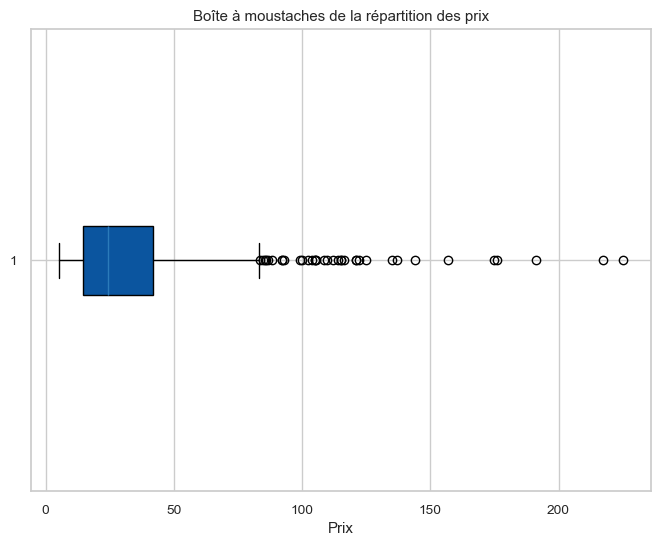

In [71]:
# Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt

price_data = df_merge_web['price']

# Créer une boîte à moustaches
plt.figure(figsize=(8, 6))
plt.boxplot(price_data, vert=False, patch_artist=True)

# Ajouter des titres et des labels
plt.title('Boîte à moustaches de la répartition des prix')
plt.xlabel('Prix')

# Afficher le graphique
plt.show()

In [72]:
#Autre méthode avec plotly express
fig = px.box(df_merge_web, x="price", title="Boîte à moustaches de la répartition des prix")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [73]:
#Calculer la moyenne du prix
moyenne_prix = df_merge_web["price"].mean()
print("Moyenne du prix :", moyenne_prix)
#Calculer l'écart-type du prix
ecart_type_prix = df_merge_web["price"].std()
print("Écart-type du prix :", ecart_type_prix)
#Calculer le Z-score
df_merge_web["z_score_price"] = (df_merge_web["price"] - moyenne_prix) / ecart_type_prix
df_merge_web[["product_id", "price", "z_score_price"]]

Moyenne du prix : 32.27763636363637
Écart-type du prix : 26.603195978591984


,product_id,price,z_score_price
0,3847,24.2,-0.303634
1,3849,34.3,0.076020
2,3850,20.8,-0.431438
3,4032,14.1,-0.683288
4,4039,46.0,0.515816
...,...,...,...
820,7203,45.0,0.478227
821,7204,45.0,0.478227
822,7247,54.8,0.846604
823,7329,26.5,-0.217178


In [74]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix_z3 = moyenne_prix + 3 * ecart_type_prix
print("Seuil de prix pour z-score > 3 :", seuil_prix_z3)

Seuil de prix pour z-score > 3 : 112.08722429941233


In [75]:
#Afficher les lignes dont le prix est supérieur au seuil de prix pour z-score > 3
df_merge_web[df_merge_web["price"] > seuil_prix_z3].sort_values("price", ascending=False)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_type,product_type,z_score_price
208,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,taxable,product,Champagne,7.244331
460,5001,1,217.5,18,instock,116.87,14581,14581,2.0,taxable,product,Vin,6.962410
635,5892,1,191.3,98,instock,116.06,14983,14983,6.0,taxable,product,Champagne,5.977566
227,4402,1,176.0,11,instock,78.25,3510,3510,3.0,taxable,product,Cognac,5.402447
598,5767,1,175.0,12,instock,90.42,15185,15185,4.0,taxable,product,Vin,5.364858
230,4406,1,157.0,12,instock,69.08,7819,7819,4.0,taxable,product,Cognac,4.688247
242,4594,1,144.0,0,outofstock,87.36,NaN,NaN,NaN,NaN,NaN,NaN,4.199584
411,4904,1,137.0,9,instock,67.95,14220,14220,3.0,taxable,product,Vin,3.936458
697,6126,1,135.0,138,instock,80.33,14923,14923,5.0,taxable,product,Champagne,3.861279
556,5612,1,124.8,19,instock,66.41,14915,14915,1.0,taxable,product,Vin,3.477866


In [76]:
# Tri pour que le graphique soit plus lisible (du moins cher au plus cher)
import plotly.graph_objects as go

tmp = df_merge_web.sort_values("price").reset_index(drop=True)
tmp["outlier_z3"] = tmp["z_score_price"] > 3

fig = px.scatter(
    tmp,
    x=tmp.index,
    y="price",
    color="outlier_z3",
    title="Prix triés — Seuil Z-score > 3",
    labels={"x": "Produits (index trié)", "price": "Prix (€)", "outlier_z3": "Outlier (z>3)"}
)

# Ligne seuil
fig.add_hline(y=seuil_prix_z3, line_dash="dash", annotation_text="Seuil z>3", annotation_position="top left")

fig.show()

D'après l'analyse du tableau, le Z-score (>3) identifie **17 produits** dont le prix est **supérieur à 112 €**. Les prix vont de **114 €** à **225 €**. Les catégories (Champagne, Cognac, Vin premium) et la cohérence avec le prix d’achat plus la présence de ventes suggèrent qu’il s’agit majoritairement de ***produits haut de gamme, pas d’erreurs***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [77]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge_web["price"].describe()

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [78]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge_web["price"].quantile(0.25)
Q3 = df_merge_web["price"].quantile(0.75)
IQR = Q3 - Q1

borne_sup = Q3 + 1.5 * IQR
borne_inf = Q1 - 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Borne inf :", borne_inf)
print("Borne sup :", borne_sup)

Q1 : 14.5
Q3 : 42.0
IQR : 27.5
Borne inf : -26.75
Borne sup : 83.25


In [79]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_merge_web[df_merge_web["price"] > borne_sup]
nb_outliers = outliers_iqr.shape[0]
proportion_outliers = nb_outliers / df_merge_web.shape[0] * 100

print("Nombre d'articles outliers (IQR) :", nb_outliers)
print("Proportion d'outliers (%) :", proportion_outliers)

Nombre d'articles outliers (IQR) : 36
Proportion d'outliers (%) : 4.363636363636364


In [80]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers_iqr[["product_id", "price", "purchase_price", "total_sales", "product_type"]].sort_values("price", ascending=False)

,product_id,price,purchase_price,total_sales,product_type
208,4352,225.0,137.81,11.0,Champagne
460,5001,217.5,116.87,2.0,Vin
635,5892,191.3,116.06,6.0,Champagne
227,4402,176.0,78.25,3.0,Cognac
598,5767,175.0,90.42,4.0,Vin
230,4406,157.0,69.08,4.0,Cognac
242,4594,144.0,87.36,NaN,NaN
411,4904,137.0,67.95,3.0,Vin
697,6126,135.0,80.33,5.0,Champagne
556,5612,124.8,66.41,1.0,Vin


In [81]:
fig = px.box(
    df_merge_web,
    y="price",
    title="Boxplot des prix — Méthode IQR",
    labels={"price": "Prix (€)"}
)

fig.add_hline(y=borne_sup, line_dash="dash", annotation_text="Borne sup IQR", annotation_position="top left")
fig.show()

Les outliers IQR semblent majoritairement **justifiés** : ils correspondent à ***des produits haut de gamme***, avec *un prix d’achat cohérent* et *des ventes observées*

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [82]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge_web_supp["ca_par_article"] = df_merge_web_supp["price"] * df_merge_web_supp["total_sales"]
#Calculer la somme de la colonne "ca_par_article"
ca_total = df_merge_web_supp["ca_par_article"].sum().round(2)
#Ce résultat correspond au chiffre d'affaire du site web
print("Chiffre d'affaires total du site web :", ca_total,"€")

Chiffre d'affaires total du site web : 143680.1 €


In [83]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_ca_sorted = df_merge_web_supp.sort_values("ca_par_article", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_ca_sorted = df_ca_sorted.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
top20_ca = df_ca_sorted.head(20)
top20_ca[["product_id", "id_web","product_type", "price", "total_sales", "ca_par_article"]]


,product_id,id_web,product_type,price,total_sales,ca_par_article
0,4352,15940,Champagne,225.0,11.0,2475.0
1,5892,14983,Champagne,191.3,6.0,1147.8
2,4353,12587,Champagne,79.5,14.0,1113.0
3,5826,15325,Vin,41.2,20.0,824.0
4,6212,13996,Vin,115.0,7.0,805.0
5,5026,13913,Champagne,86.8,9.0,781.2
6,5008,11602,Vin,105.0,7.0,735.0
7,5767,15185,Vin,175.0,4.0,700.0
8,6126,14923,Champagne,135.0,5.0,675.0
9,5025,13914,Champagne,112.0,6.0,672.0


In [84]:
#Graphique en barre des 20 premiers articles avec plotly express
top20_ca = df_merge_web_supp.sort_values("ca_par_article", ascending=False).head(20).copy()
top20_ca["product_id_str"] = top20_ca["product_id"].astype(str)

fig = px.bar(
    top20_ca,
    x="product_id_str",
    y="ca_par_article",
    color="product_type",
    title="Top 20 articles par chiffre d'affaires",
    labels={"product_id_str": "Product ID", "ca_par_article": "CA (€)", "product_type": "Type produit"},
    hover_data=["product_type", "price", "total_sales"]
)

fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.0f} €", textposition="outside")
fig.update_layout(yaxis_range=[0, top20_ca["ca_par_article"].max() * 1.1])

fig.update_xaxes(categoryorder="array", categoryarray=top20_ca["product_id_str"].tolist())

fig.show()

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Meme palmares avec la charte de restitution.</b> La veille a tranche : Plotly reste utile pour explorer a l'ecran, mais les figures destinees a la presentation sont produites avec matplotlib et seaborn, parce qu'elles s'exportent en image fixe et se collent telles quelles dans les slides. Le graphique ci-dessous est enregistre dans le dossier de sorties.</p>
</div>

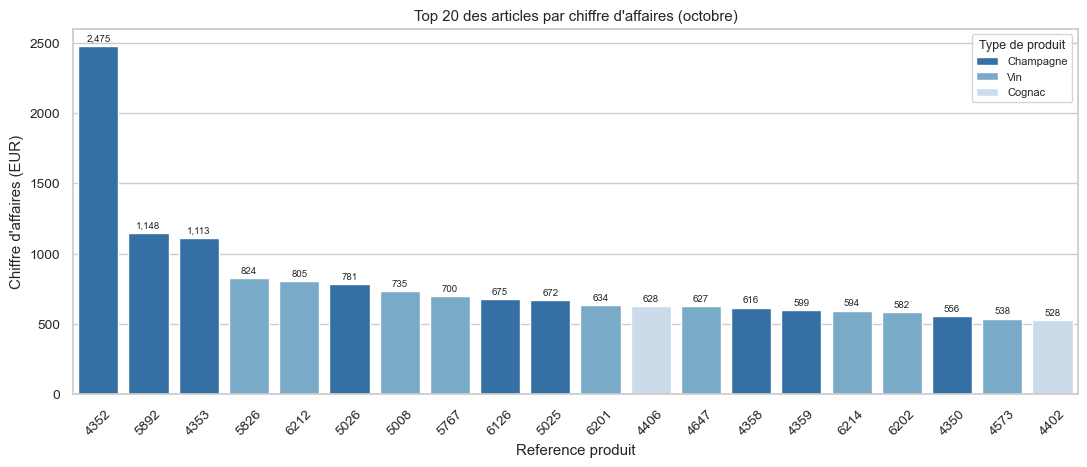

In [85]:
# [AJOUT v2] Top 20 CA avec la charte de restitution (matplotlib / seaborn), exporte en image pour la presentation
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(data=top20_ca, x="product_id_str", y="ca_par_article", hue="product_type", dodge=False, ax=ax, palette="Blues_r")
ax.set_title("Top 20 des articles par chiffre d'affaires (octobre)")
ax.set_xlabel("Reference produit")
ax.set_ylabel("Chiffre d'affaires (EUR)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type de produit", fontsize=8, title_fontsize=9)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=7, xytext=(0, 2), textcoords="offset points")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top20_ca.png", dpi=150)
plt.show()

In [86]:
#############################
# Calculer le 20 / 80 en CA #
#############################
#Trier par CA décroissant
df_pareto = df_merge_web_supp.sort_values("ca_par_article", ascending=False).reset_index(drop=True)
#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_pareto["part_ca"] = df_pareto["ca_par_article"] / ca_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_pareto["part_ca_cumulee"] = df_pareto["part_ca"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = (df_pareto["part_ca_cumulee"] <= 0.80).sum()
print("Nombre d'articles représentant ~80% du CA :", nb_articles_80)
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80 = round(nb_articles_80 / df_pareto.shape[0] * 100, 2)
print("Proportion d'articles correspondant à 80% du CA (%):", proportion_articles_80,"%")

Nombre d'articles représentant ~80% du CA : 434
Proportion d'articles correspondant à 80% du CA (%): 60.78 %


Environ **80% du chiffre d’affaires** est généré par **434 références**, soit **60,78% du catalogue web**. Le CA est donc réparti sur un grand nombre de produits, et ***ne suit pas un schéma 80/20 très concentré***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [87]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_qte_sorted = df_merge_web_supp.sort_values("total_sales", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_qte_sorted = df_qte_sorted.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
top20_qte = df_qte_sorted.head(20)
top20_qte[["product_id", "id_web", "total_sales", "price", "ca_par_article", "product_type"]]
#Graphique en barre des 20 premiers articles avec plotly express
top20_qte = top20_qte.copy()
top20_qte["product_id_str"] = top20_qte["product_id"].astype(str)

fig = px.bar(
    top20_qte,
    x="product_id_str",
    y="total_sales",
    color="product_type",
    title="Top 20 articles par quantités vendues",
    labels={
        "product_id_str": "Product ID",
        "total_sales": "Quantités vendues",
        "product_type": "Type produit"
    },
    hover_data=["product_type", "price", "ca_par_article"]
)

fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.0f}", textposition="outside")
fig.update_layout(yaxis_range=[0, top20_qte["total_sales"].max() * 1.1])
fig.update_xaxes(categoryorder="array", categoryarray=top20_qte["product_id_str"].tolist())

fig.show()

In [88]:
#############################
# Calculer le 20 / 80 en CA #
#############################
#Trier par quantités vendues décroissant
df_pareto_qte = df_merge_web_supp.sort_values("total_sales", ascending=False).reset_index(drop=True)
#Créer une colonne calculant la part en quantité de la ligne dans le dataset
qte_total = df_pareto_qte["total_sales"].sum()
df_pareto_qte["part_qte"] = df_pareto_qte["total_sales"] / qte_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_pareto_qte["part_qte_cumule"] = df_pareto_qte["part_qte"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte = (df_pareto_qte["part_qte_cumule"] <= 0.80).sum()
print("Nombre d'articles représentant ~80% des ventes (quantité) :", nb_articles_80_qte)
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_qte = round(nb_articles_80_qte / df_pareto_qte.shape[0] * 100, 2)
print("Proportion d'articles correspondant à 80% des ventes (quantité) (%) :", proportion_articles_80_qte, "%")

Nombre d'articles représentant ~80% des ventes (quantité) : 433
Proportion d'articles correspondant à 80% des ventes (quantité) (%) : 60.64 %


**80% des quantités vendues** proviennent de **433 références (60,64% du catalogue)**. C’est **très proche** du résultat en **chiffre d’affaires (434 références, 60,78%)**. Cela montre que les ventes et le CA sont répartis sur un grand nombre de produits : notre activité **n’est pas dépendante** d’un petit groupe de ***best-sellers***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [89]:
######################################
# Calculer le nombre de mois de stock #
######################################
#Création de la colonne Rotation de stock
df_merge_web["mois_de_stock"] = df_merge_web["stock_quantity"] / df_merge_web["total_sales"]
#Remplacement des "inf" par 0
df_merge_web["mois_de_stock"] = df_merge_web["mois_de_stock"].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock_sorted = df_merge_web.sort_values("mois_de_stock", ascending=False).reset_index(drop=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop20_stock = df_stock_sorted.head(20).copy()
flop20_stock["product_id_str"] = flop20_stock["product_id"].astype(str)
flop20_stock["product_type_clean"] = flop20_stock["product_type"].fillna("Inconnu").astype(str)
fig = px.bar(
    flop20_stock,
    x="product_id_str",
    y="mois_de_stock",
    color="product_type_clean",
    title="Flop 20 — Produits avec le plus de mois de stock",
    labels={
        "product_id_str": "Product ID",
        "mois_de_stock": "Mois de stock",
        "product_type_clean": "Type produit"
    },
    hover_data=["product_type_clean", "stock_quantity", "total_sales"]
)
fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.1f}", textposition="outside")
fig.update_layout(yaxis_range=[0, flop20_stock["mois_de_stock"].max() * 1.1])
fig.update_xaxes(categoryorder="array", categoryarray=flop20_stock["product_id_str"].tolist())
fig.show()

In [90]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge_web["Valorisation_stock_euros"] = df_merge_web["stock_quantity"] * df_merge_web["price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale = df_merge_web["Valorisation_stock_euros"].sum().round(2)
print("Valorisation totale des stocks :", valorisation_totale,"€")

Valorisation totale des stocks : 532119.1 €


<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Complement : valorisation au prix d'achat.</b> La version initiale valorisait le stock au prix de vente et signalait qu'une vision plus financiere se ferait au prix d'achat, sans la calculer. C'est fait ici. J'isole aussi ce que le comite de direction appelle l'argent qui dort : les references en stock qui n'ont enregistre aucune vente sur le mois. Je distingue deux cas, parce qu'ils n'appellent pas la meme action : les produits qui ont une page web et ne se vendent pas, et les produits qui n'ont pas de page web, donc qui ne peuvent pas se vendre en ligne.</p>
<p>Attention a la lecture de l'ecart entre les deux valorisations : le prix de vente de l'ERP est toutes taxes comprises alors que le prix d'achat est hors taxes. L'ecart n'est donc pas une marge nette, il donne un ordre de grandeur.</p>
</div>

In [91]:
# [AJOUT v2] Valorisation du stock au prix d'achat et reperage de l'argent qui dort
df_merge_web["valorisation_stock_achat"] = df_merge_web["stock_quantity"] * df_merge_web["purchase_price"]
valo_achat = round(df_merge_web["valorisation_stock_achat"].sum(), 2)
valo_vente = round(df_merge_web["Valorisation_stock_euros"].sum(), 2)

print(f"Valorisation du stock au prix de vente (TTC) : {valo_vente:>12,.2f} EUR")
print(f"Valorisation du stock au prix d'achat  (HT)  : {valo_achat:>12,.2f} EUR")
print(f"Ecart (ordre de grandeur, TTC contre HT)     : {valo_vente - valo_achat:>12,.2f} EUR")

en_stock = df_merge_web["stock_quantity"] > 0
sans_vente = df_merge_web["total_sales"].fillna(0) == 0
avec_page = df_merge_web["sku"].notna()

dort_avec_page = df_merge_web[en_stock & sans_vente & avec_page]
dort_sans_page = df_merge_web[en_stock & sans_vente & ~avec_page]

print(f"\nReferences en stock sans aucune vente en octobre :")
print(f"  avec une page web (a relancer ou a destocker) : {len(dort_avec_page):>4} references, "
      f"{dort_avec_page['valorisation_stock_achat'].sum():>10,.2f} EUR au prix d'achat")
print(f"  sans page web (invendables en ligne)           : {len(dort_sans_page):>4} references, "
      f"{dort_sans_page['valorisation_stock_achat'].sum():>10,.2f} EUR au prix d'achat")

dort_avec_page.sort_values("valorisation_stock_achat", ascending=False)[
    ["product_id", "product_type", "stock_quantity", "purchase_price", "valorisation_stock_achat"]
].head(10)

Valorisation du stock au prix de vente (TTC) :   532,119.10 EUR
Valorisation du stock au prix d'achat  (HT)  :   298,627.66 EUR
Ecart (ordre de grandeur, TTC contre HT)     :   233,491.44 EUR

References en stock sans aucune vente en octobre :
  avec une page web (a relancer ou a destocker) :    3 references,  14,959.40 EUR au prix d'achat
  sans page web (invendables en ligne)           :   64 references,  21,299.59 EUR au prix d'achat


,product_id,product_type,stock_quantity,purchase_price,valorisation_stock_achat
210,4355,Champagne,97,77.48,7515.56
205,4337,Champagne,145,48.90,7090.50
656,5932,Cognac,13,27.18,353.34


Ici c’est une valorisation au prix de vente, pas une valorisation comptable, **le stock représente 532119.1€ de valeur au prix de vente**.
Une valorisation plus “finance” se ferait plutôt au prix d’achat (purchase_price) ou au coût.

In [92]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_total = df_merge_web["stock_quantity"].sum()
print("Nombre total d'unités en stock :", stock_total)

Nombre total d'unités en stock : 17822


On a :

17 822 unités en stock.

532 119,10 € de valorisation au prix de vente.

Donc l’entreprise a ***un stock important***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [93]:
############################
# Analyse du taux de marge #
############################
#Si tax_status == "taxable" → prix HT = prix TTC / 1.20 (TVA 20%)
#Sinon (ex “none”) → prix HT = prix
#Création de la colonne Prix HT
df_merge_web_supp["prix_ht"] = df_merge_web_supp.apply(
    lambda row: row["price"] / 1.20 if row["tax_status"] == "taxable" else row["price"],
    axis=1
)
#Création de la colonne Taux de marge
#taux_marge = (prix_ht - prix_achat) / prix_achat
df_merge_web_supp["taux_marge"] = (df_merge_web_supp["prix_ht"] - df_merge_web_supp["purchase_price"]) / df_merge_web_supp["purchase_price"]
#Afficher le prix minimum de la colonne "taux_marge"
taux_min = df_merge_web_supp["taux_marge"].min()
print(f"Taux de marge minimum : {taux_min:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_max = df_merge_web_supp["taux_marge"].max()
print(f"Taux de marge maximum : {taux_max:.2%}")

Taux de marge minimum : -86.39%
Taux de marge maximum : 91.41%


Le taux de marge observé varie entre -86,39% et +91,41%.

- **Une marge positive (jusqu’à +91,41%)** signifie que le prix HT est supérieur au prix d’achat : ces références génèrent **une marge commerciale importante**.

- **Une marge négative (jusqu’à -86,39%)** indique que le prix HT est inférieur au prix d’achat : cela peut correspondre à **une vente à perte** (promotion/déstockage) ou **révéler une incohérence de données (erreur de saisie sur le prix d’achat ou le prix de vente)**.

In [94]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge_web_supp[df_merge_web_supp["taux_marge"] < 0][
    ["product_id", "id_web", "price", "prix_ht", "purchase_price", "taux_marge", "total_sales", "product_type"]
].sort_values("taux_marge").head(10)

,product_id,id_web,price,prix_ht,purchase_price,taux_marge,total_sales,product_type
210,4355,12589,12.65,10.541667,77.48,-0.863943,0.0,Champagne


Comme **aucune vente** n’est enregistrée sur la période (total_sales = 0), ce cas est très probablement lié à ***une erreur de saisie sur le prix d’achat ou le prix de vente***, plutôt qu’à une promotion réelle. Ce produit doit être vérifié et corrigé dans l’ERP.

In [95]:
#Création d'un dataframe avec les taux positifs
df_taux_pos = df_merge_web_supp[df_merge_web_supp["taux_marge"] >= 0].copy()
#Afficher le prix minimum de la colonne "taux_marge"
taux_min_pos = df_taux_pos["taux_marge"].min()
print(f"Taux de marge min (positifs) : {taux_min_pos:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_max_pos = df_taux_pos["taux_marge"].max()
print(f"Taux de marge max (positifs) : {taux_max_pos:.2%}")

Taux de marge min (positifs) : 29.50%
Taux de marge max (positifs) : 91.41%


In [96]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_par_type = (
    df_taux_pos.groupby("product_type", dropna=False)["taux_marge"]
    .mean()
    .reset_index()
)

# en % pour lecture facile
df_marge_par_type["taux_marge_pct"] = df_marge_par_type["taux_marge"] * 100
df_marge_par_type.sort_values("taux_marge_pct", ascending=False)
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_par_type.sort_values("taux_marge_pct", ascending=False),
    x="product_type",
    y="taux_marge_pct",
    title="Taux de marge moyen par type de produit",
    labels={"product_type": "Type de produit", "taux_marge_pct": "Taux de marge moyen (%)"}
)

fig.update_traces(texttemplate="%{y:.1f}%", textposition="outside")
fig.update_layout(yaxis_range=[0, df_marge_par_type["taux_marge_pct"].max() * 1.2])
fig.show()

Les marges moyennes varient fortement selon la catégorie :** Cognac et Whisky dépassent 80%** en moyenne, Gin 75%, Vin 61%. À l’inverse,** Champagne (40%)** et **Huile d’olive (33%)** sont nettement moins margés. Cela suggère que ***les spiritueux sont les plus rentables*** à l’unité, tandis que ***Champagne/Huile d’olive nécessitent un pilotage prix/achats plus fin***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Modification.</b> Nicolas demandait une correlation entre prix, prix d'achat, stock, ventes, prix hors taxes et taux de marge. La version initiale n'en croisait que trois. Les six variables sont maintenant croisees dans une seule matrice, affichee en triangle pour eviter les doublons. Les deux imports repetes de la version initiale (numpy et matplotlib au milieu du notebook) sont supprimes : tout est importe une fois, en tete.</p>
</div>

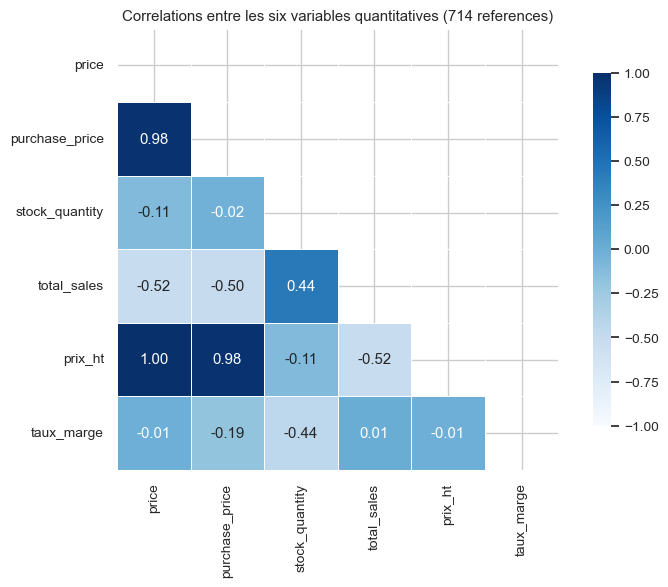

,price,purchase_price,stock_quantity,total_sales,prix_ht,taux_marge
price,1.00,0.98,-0.11,-0.52,1.00,-0.01
purchase_price,0.98,1.00,-0.02,-0.50,0.98,-0.19
stock_quantity,-0.11,-0.02,1.00,0.44,-0.11,-0.44
total_sales,-0.52,-0.50,0.44,1.00,-0.52,0.01
prix_ht,1.00,0.98,-0.11,-0.52,1.00,-0.01
taux_marge,-0.01,-0.19,-0.44,0.01,-0.01,1.00


In [97]:
# [MODIFIE v2] Correlations etendues aux six variables demandees, en une seule matrice
cols_corr = ["price", "purchase_price", "stock_quantity", "total_sales", "prix_ht", "taux_marge"]
corr_matrix = df_merge_web_supp[cols_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlations entre les six variables quantitatives (714 references)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlations.png", dpi=150)
plt.show()
corr_matrix.round(2)

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Lecture des correlations etendues.</b> Les trois correlations de la version initiale sont inchangees : prix et ventes a -0,52, ventes et stock a +0,44, prix et stock a -0,11. Les nouvelles variables apportent trois enseignements.</p>
<ul>
<li><b>Prix de vente et prix d'achat : +0,98.</b> La grille tarifaire est tres coherente avec les couts : les produits chers a l'achat sont chers a la vente. C'est rassurant sur la qualite des prix dans l'ERP, hors les quelques anomalies deja signalees.</li>
<li><b>Stock et taux de marge : -0,44.</b> Plus la marge est faible, plus le stock est eleve. Les produits a faible marge sont ceux qui s'accumulent. C'est un signal direct pour l'assortiment : ce sont ces references qui meritent d'etre revues en priorite.</li>
<li><b>Prix d'achat et ventes : -0,50.</b> Meme lecture que pour le prix de vente : les produits couteux se vendent en plus petites quantites, ce qui est attendu pour du vin et des spiritueux haut de gamme.</li>
</ul>
<p>Le prix hors taxes se comporte comme le prix de vente (+1,00), ce qui est mecanique puisque toutes les references sont taxables au meme taux. Le taux de marge est quasiment independant du prix (-0,01) : la marge n'est pas plus forte sur les produits chers. Rappel de prudence : une correlation mesure une association, pas une cause, et ces resultats portent sur un seul mois.</p>
</div>

***Conclusion corrélation :***

**- price vs total_sales : corrélation ≈ -0,52 (négative modérée)**
Plus le prix augmente, plus les quantités vendues ont tendance à diminuer. C’est cohérent : des produits plus chers se vendent généralement moins en volume.

**- total_sales vs stock_quantity : corrélation ≈ +0,44 (positive modérée)**
Les produits qui se vendent le plus sont aussi ceux qui ont tendance à avoir plus de stock disponible. Cela suggère une logique de gestion de stock orientée vers les produits “best-sellers”.

**- price vs stock_quantity : corrélation ≈ -0,11 (négative faible)**
Il n’y a pas de relation forte entre le prix et le stock. Le niveau de stock ne semble pas dépendre directement du prix, ou alors l’effet est très léger.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [98]:
# [MODIFIE v2] Export du dataset final dans le dossier de sorties du projet (chemin relatif)
df_final = df_merge_web_supp.copy()

print("Dimensions df_final (lignes, colonnes) :", df_final.shape)
print("\nValeurs manquantes par colonne :")
print(df_final.isna().sum().sort_values(ascending=False).head(10))

chemin_export = OUTPUT_DIR / "df_final_merge_web_supp.xlsx"
df_final.to_excel(chemin_export, index=False)
print(f"\nFichier Excel cree : {chemin_export}")
# Cette etape permet de partager le resultat avec les equipes et servira de base au futur projet de visualisation.

Dimensions df_final (lignes, colonnes) : (714, 15)

Valeurs manquantes par colonne :
product_type      1
onsale_web        0
product_id        0
stock_quantity    0
stock_status      0
purchase_price    0
price             0
id_web            0
sku               0
tax_status        0
dtype: int64

Fichier Excel cree : ..\outputs\df_final_merge_web_supp.xlsx


<div style="background-color: #C00000;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Synthese qualite des donnees, controle final et limites <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h2>
</div>

<div style="border: 1px solid #C00000;" >
<h3 style="margin: auto; padding: 20px; color: #C00000; ">6.1 - Tableau recapitulatif des anomalies et recommandations <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Pourquoi ce tableau.</b> Nicolas l'ecrit dans son mail : il veut comprendre les erreurs rencontrees et disposer d'un recapitulatif des corrections a mettre en place pour avoir une base propre. La version initiale detectait les anomalies mais les laissait dispersees dans le notebook. Ce tableau les consolide, avec pour chacune : le type, le nombre de lignes, la correction appliquee dans l'analyse, l'hypothese sur laquelle elle repose, et la recommandation pour le systeme source. Il est exporte en Excel pour etre transmis tel quel.</p>
</div>

In [99]:
# [AJOUT v2] Tableau recapitulatif des anomalies : les comptages sont recalcules a partir des donnees brutes, pas recopies
def n(masque): return int(masque.sum())
def ids(df, masque, cle="product_id", k=5): return ", ".join(str(v) for v in df.loc[masque, cle].head(k))

erp, web, lia = df_erp_brut, df_web_brut, df_liaison_brut
sku_txt = web["sku"].astype(str)
m_prix_neg   = erp["price"] < 0
m_stock_neg  = erp["stock_quantity"] < 0
m_incoh      = (erp["stock_quantity"] > 0) != (erp["stock_status"] == "instock")
m_sku_format = web["sku"].notna() & ~sku_txt.str.fullmatch(r"\d+") & (web["post_type"] == "product")
m_attach     = web["post_type"] == "attachment"
m_sans_sku   = web["sku"].isna()
m_vente_neg  = web["total_sales"] < 0
m_sans_idweb = lia["id_web"].isna()
m_idweb_fmt  = lia["id_web"].notna() & ~lia["id_web"].astype(str).str.fullmatch(r"\d+")
m_marge_neg  = df_merge_web_supp["taux_marge"] < 0

recap_anomalies = pd.DataFrame([
    {"n": 1, "anomalie": "Prix de vente negatifs", "table": "ERP", "type": "saisie",
     "nb_lignes": n(m_prix_neg), "exemples": ids(erp, m_prix_neg),
     "correction_dans_l_analyse": "Valeur absolue",
     "hypothese": "Erreur de signe : un prix de vente ne peut pas etre negatif",
     "recommandation_systeme": "Controle de saisie dans l'ERP : prix strictement positif obligatoire"},
    {"n": 2, "anomalie": "Stocks negatifs", "table": "ERP", "type": "processus / saisie",
     "nb_lignes": n(m_stock_neg), "exemples": ids(erp, m_stock_neg),
     "correction_dans_l_analyse": "Ramenes a zero",
     "hypothese": "Exces de sorties enregistrees : double scan en caisse, demarque saisie plusieurs fois ou erreur de comptage",
     "recommandation_systeme": "Interdire un stock negatif ; inventaire physique sur la reference a -10, incident isole probable sur celle a -1"},
    {"n": 3, "anomalie": "Statut de stock incoherent avec la quantite", "table": "ERP", "type": "calcul",
     "nb_lignes": n(m_incoh), "exemples": ids(erp, m_incoh),
     "correction_dans_l_analyse": "Statut recalcule a partir de la quantite",
     "hypothese": "Le statut est saisi a la main au lieu d'etre derive",
     "recommandation_systeme": "Deriver automatiquement le statut de la quantite"},
    {"n": 4, "anomalie": "Codes articles hors regle de codification", "table": "WEB / LIAISON", "type": "format",
     "nb_lignes": n(m_sku_format), "exemples": ids(web, m_sku_format, "sku"),
     "correction_dans_l_analyse": "Conserves et documentes (variante, bon cadeau)",
     "hypothese": "Produits particuliers codes manuellement",
     "recommandation_systeme": "Regle de codification unique, pas de suffixe ni de libelle dans le code"},
    {"n": 5, "anomalie": "Doublons de codes articles dus aux lignes de pieces jointes", "table": "WEB", "type": "structure de l'export",
     "nb_lignes": n(m_attach), "exemples": ids(web, m_attach, "sku"),
     "correction_dans_l_analyse": "Filtre sur les lignes de type produit",
     "hypothese": "L'export melange produits et images attachees",
     "recommandation_systeme": "Limiter l'export aux produits"},
    {"n": 6, "anomalie": "Lignes sans code article", "table": "WEB", "type": "export",
     "nb_lignes": n(m_sans_sku), "exemples": "",
     "correction_dans_l_analyse": "Supprimees",
     "hypothese": "Lignes techniques ou fiches incompletes",
     "recommandation_systeme": "Nettoyer l'export a la source"},
    {"n": 7, "anomalie": "Quantites vendues negatives (nouveau, detecte par le controle automatise)", "table": "WEB", "type": "saisie",
     "nb_lignes": n(m_vente_neg), "exemples": "lignes sans code article",
     "correction_dans_l_analyse": "Exclues avec les lignes sans code article ; non vues dans la version initiale",
     "hypothese": "Retours ou annulations comptabilises en negatif sur des fiches sans reference",
     "recommandation_systeme": "Verifier le traitement des retours dans le module de vente"},
    {"n": 8, "anomalie": "References ERP sans identifiant web dans la liaison", "table": "LIAISON", "type": "jointure",
     "nb_lignes": n(m_sans_idweb), "exemples": ids(lia, m_sans_idweb),
     "correction_dans_l_analyse": "Exclues du CA, conservees pour le stock",
     "hypothese": "Table de liaison non mise a jour pour ces produits",
     "recommandation_systeme": "Completer la liaison ; l'alerte de l'etape 3.2 suit ce taux chaque mois"},
    {"n": 9, "anomalie": "Identifiants web renseignes mais absents du site", "table": "LIAISON / WEB", "type": "synchronisation",
     "nb_lignes": nb_id_web_sans_page, "exemples": ", ".join(str(v) for v in ids_web_probleme[:5]),
     "correction_dans_l_analyse": "Exclus du CA",
     "hypothese": "Produits retires du site ou identifiant mal saisi",
     "recommandation_systeme": "Synchroniser la liaison avec le site a chaque export"},
    {"n": 10, "anomalie": "Identifiant web hors format dans la liaison", "table": "LIAISON", "type": "format",
     "nb_lignes": n(m_idweb_fmt), "exemples": ", ".join(str(v) for v in lia.loc[m_idweb_fmt, "id_web"]),
     "correction_dans_l_analyse": "Conserves, jointure sur texte",
     "hypothese": "Meme cause que l'anomalie 4",
     "recommandation_systeme": "Meme regle de codification que le site"},
    {"n": 11, "anomalie": "Taux de marge negatif", "table": "ERP", "type": "saisie de prix",
     "nb_lignes": n(m_marge_neg), "exemples": ids(df_merge_web_supp, m_marge_neg),
     "correction_dans_l_analyse": "Signale, non corrige",
     "hypothese": "Prix d'achat ou prix de vente errone (aucune vente sur la periode)",
     "recommandation_systeme": "Verifier les deux prix dans l'ERP"},
    {"n": 12, "anomalie": "Colonne a caractere personnel dans l'export web", "table": "WEB", "type": "RGPD",
     "nb_lignes": int(web["post_author"].notna().sum()), "exemples": "post_author",
     "correction_dans_l_analyse": "Colonne ecartee (minimisation)",
     "hypothese": "Export brut de la base WordPress",
     "recommandation_systeme": "Ne pas exporter les colonnes d'utilisateurs"},
    {"n": 13, "anomalie": "Types heterogenes des cles de jointure", "table": "ERP / WEB / LIAISON", "type": "type",
     "nb_lignes": 0, "exemples": "product_id entier ; sku et id_web texte",
     "correction_dans_l_analyse": "Jointure sur le type texte",
     "hypothese": "Deux systemes, deux conventions",
     "recommandation_systeme": "Typage unique et documente des identifiants"},
])

recap_anomalies.to_excel(OUTPUT_DIR / "recap_anomalies.xlsx", index=False)
print(f"{len(recap_anomalies)} anomalies consolidees. Fichier : {OUTPUT_DIR / 'recap_anomalies.xlsx'}")
pd.set_option("display.max_colwidth", 60)
recap_anomalies[["n", "anomalie", "table", "type", "nb_lignes", "correction_dans_l_analyse", "recommandation_systeme"]]

13 anomalies consolidees. Fichier : ..\outputs\recap_anomalies.xlsx


,n,anomalie,table,type,nb_lignes,correction_dans_l_analyse,recommandation_systeme
0,1,Prix de vente negatifs,ERP,saisie,3,Valeur absolue,Controle de saisie dans l'ERP : prix strictement positif...
1,2,Stocks negatifs,ERP,processus / saisie,2,Ramenes a zero,Interdire un stock negatif ; inventaire physique sur la ...
2,3,Statut de stock incoherent avec la quantite,ERP,calcul,2,Statut recalcule a partir de la quantite,Deriver automatiquement le statut de la quantite
3,4,Codes articles hors regle de codification,WEB / LIAISON,format,2,"Conserves et documentes (variante, bon cadeau)","Regle de codification unique, pas de suffixe ni de libel..."
4,5,Doublons de codes articles dus aux lignes de pieces jointes,WEB,structure de l'export,714,Filtre sur les lignes de type produit,Limiter l'export aux produits
5,6,Lignes sans code article,WEB,export,85,Supprimees,Nettoyer l'export a la source
6,7,"Quantites vendues negatives (nouveau, detecte par le con...",WEB,saisie,2,Exclues avec les lignes sans code article ; non vues dan...,Verifier le traitement des retours dans le module de vente
7,8,References ERP sans identifiant web dans la liaison,LIAISON,jointure,91,"Exclues du CA, conservees pour le stock",Completer la liaison ; l'alerte de l'etape 3.2 suit ce t...
8,9,Identifiants web renseignes mais absents du site,LIAISON / WEB,synchronisation,20,Exclus du CA,Synchroniser la liaison avec le site a chaque export
9,10,Identifiant web hors format dans la liaison,LIAISON,format,3,"Conserves, jointure sur texte",Meme regle de codification que le site


<div style="border: 1px solid #C00000;" >
<h3 style="margin: auto; padding: 20px; color: #C00000; ">6.2 - Controle final : le jeu de donnees nettoye respecte-t-il toutes les regles ? <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Ce que verifie cette cellule.</b> Le cahier des charges fixe des criteres d'acceptation chiffres : zero prix negatif, zero stock negatif, coherence totale entre statut et quantite, aucun doublon de cle. Plutot que de l'affirmer, je rejoue le meme schema Pandera qu'a l'import, cette fois sur la table ERP nettoyee. Si elle est conforme, les criteres sont atteints. Sinon, le rapport dit exactement ce qui manque.</p>
</div>

In [100]:
# [AJOUT v2] Controle final : meme schema qu'a l'import, applique a la table ERP nettoyee
rapport_erp_final, erp_final_conforme = rapport_pandera(schema_erp, df_erp, "product_id", "erp_nettoye")

print("Criteres d'acceptation du cahier des charges (qualite des donnees)")
print(f"  Prix negatifs dans la table finale          : {int((df_erp['price'] < 0).sum())}  (attendu 0)")
print(f"  Stocks negatifs dans la table finale        : {int((df_erp['stock_quantity'] < 0).sum())}  (attendu 0)")
print(f"  Coherence statut / quantite                 : {int(((df_erp['stock_quantity'] > 0) == (df_erp['stock_status'] == 'instock')).sum())} / {len(df_erp)}  (attendu {len(df_erp)})")
print(f"  Doublons sur product_id                     : {int(df_erp['product_id'].duplicated().sum())}  (attendu 0)")
print(f"  Doublons sur sku (table web nettoyee)       : {int(df_web['sku'].duplicated().sum())}  (attendu 0)")
print(f"  Taux de non-correspondance ERP / web mesure : {taux:.1%}  (reference 13,5 %)")
print(f"  Chiffre d'affaires reproduit                : {ca_total:,.2f} EUR  (reference 143 680,10)")
print()
afficher_rapport_lisible(rapport_erp_final, "CONTROLE FINAL SUR LA TABLE ERP NETTOYEE")
assert erp_final_conforme, "La table ERP nettoyee ne respecte pas toutes les regles"
assert abs(ca_total - 143680.10) < 0.01, "Le chiffre d'affaires ne correspond pas a la reference"
print("\nTous les criteres d'acceptation sur la qualite des donnees sont atteints.")

Criteres d'acceptation du cahier des charges (qualite des donnees)
  Prix negatifs dans la table finale          : 0  (attendu 0)
  Stocks negatifs dans la table finale        : 0  (attendu 0)
  Coherence statut / quantite                 : 825 / 825  (attendu 825)
  Doublons sur product_id                     : 0  (attendu 0)
  Doublons sur sku (table web nettoyee)       : 0  (attendu 0)
  Taux de non-correspondance ERP / web mesure : 13.5%  (reference 13,5 %)
  Chiffre d'affaires reproduit                : 143,680.10 EUR  (reference 143 680,10)

CONTROLE FINAL SUR LA TABLE ERP NETTOYEE
Aucune anomalie detectee : toutes les regles sont respectees.

Tous les criteres d'acceptation sur la qualite des donnees sont atteints.


<div style="border: 1px solid #C00000;" >
<h3 style="margin: auto; padding: 20px; color: #C00000; ">6.3 - Hypotheses, limites et biais <span style="font-size:60%; font-weight:normal;">(ajout version 2)</span></h3>
</div>

<div style="color:#C00000; border-left:5px solid #C00000; padding:6px 14px; margin:6px 0;">
<p><b>Ce que je ne peux pas garantir, ecrit noir sur blanc.</b></p>
<ul>
<li><b>Un seul mois.</b> Toutes les conclusions portent sur octobre. Aucune saisonnalite, aucune tendance, aucune prevision ne peut en etre tiree. Les produits sans vente en octobre ne sont pas forcement des produits sans vente.</li>
<li><b>Les corrections reposent sur des hypotheses.</b> Un prix negatif corrige en valeur absolue suppose une erreur de signe. Un stock negatif ramene a zero suppose un exces de sorties enregistrees. Ces hypotheses sont plausibles et documentees, mais seule une verification dans l'ERP ou un inventaire physique peut les confirmer. C'est pourquoi chaque correction est aussi une recommandation.</li>
<li><b>111 references hors du chiffre d'affaires.</b> Le CA et les marges portent sur 714 references, pas 825. Si la table de liaison etait complete, le CA total serait different. Le taux de non-correspondance est suivi pour cette raison.</li>
<li><b>La TVA est supposee uniforme.</b> Le prix hors taxes est calcule avec un taux de 20 % pour toutes les references taxables. Si certains produits relevent d'un autre taux, les marges correspondantes sont legerement faussees.</li>
<li><b>Correlation n'est pas causalite.</b> Le lien entre faible marge et stock eleve est une association observee, pas une explication.</li>
<li><b>Le code assiste par IA a ete teste, pas prouve.</b> Les tests portent sur les cas connus du projet 6. Un type d'anomalie absent d'octobre et absent des regles ne serait pas detecte. Les regles doivent evoluer avec les anomalies rencontrees.</li>
</ul>
<h3 style="color:#C00000;">Ce qu'il reste a faire pour que ces controles servent chaque mois</h3>
<p>Deposer les nouveaux exports dans le dossier <code>data/</code> en gardant les memes noms de fichiers, executer le notebook de bout en bout, lire le rapport en francais de la section 1.3 et l'alerte de l'etape 3.2, puis transmettre le fichier <code>recap_anomalies.xlsx</code> et la liste des references sans correspondance. Le fichier <code>README.md</code> du projet detaille ces etapes. La validation en ligne de commande apparue dans la version 0.33 de Pandera permettrait a terme de lancer les controles sans ouvrir le notebook : c'est la piste d'amelioration prioritaire.</p>
</div>